# Sensor Calibration Deployment Example

This notebook loads a stored campaign calibration model and applies it to another
campaign with partial sensor overlap.

Example configuration:
- train artifact: `MeasurementCalibration`
- deployment campaign: `test-calibration`

The notebook does not retrain anything. It only reloads the persisted artifact,
matches the deployment campaign to the shared sensors, and applies the deployed
gain and additive-noise correction.


In [1]:
from __future__ import annotations

import importlib
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


def resolve_repo_root() -> Path:
    """Return the repository root regardless of the notebook launch directory."""

    current = Path.cwd().resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if (candidate / "measurement_calibration").exists() and (
            candidate / "data"
        ).exists():
            return candidate
    raise RuntimeError(
        "Could not locate the repository root from the current notebook session"
    )


def power_linear_to_plot_db(
    power_linear: np.ndarray,
    floor_power: float = 1.0e-18,
) -> np.ndarray:
    """Convert linear power to dB with a plotting floor below the solver floor."""

    return 10.0 * np.log10(
        np.clip(np.asarray(power_linear, dtype=np.float64), floor_power, None)
    )


REPO_ROOT = resolve_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import measurement_calibration.artifacts as artifacts_module  # noqa: E402
import measurement_calibration.campaign_calibration as campaign_calibration_module  # noqa: E402
import measurement_calibration.spectral_calibration as spectral_calibration_module  # noqa: E402

artifacts_module = importlib.reload(artifacts_module)
campaign_calibration_module = importlib.reload(campaign_calibration_module)
spectral_calibration_module = importlib.reload(spectral_calibration_module)

build_campaign_deployment_inputs = (
    campaign_calibration_module.build_campaign_deployment_inputs
)
prepare_campaign_calibration_dataset = (
    campaign_calibration_module.prepare_campaign_calibration_dataset
)
load_spectral_calibration_artifact = (
    artifacts_module.load_spectral_calibration_artifact
)
apply_deployed_calibration = (
    spectral_calibration_module.apply_deployed_calibration
)
compute_network_consensus = (
    spectral_calibration_module.compute_network_consensus
)
power_linear_to_db = spectral_calibration_module.power_linear_to_db

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

CAMPAIGNS_ROOT = REPO_ROOT / "data" / "campaigns"
MODELS_ROOT = REPO_ROOT / "models" / "campaign_spectral_calibration"
TRAINING_CAMPAIGN_LABEL = "MeasurementCalibration"
DEPLOYMENT_CAMPAIGN_LABEL = "test-calibration"
RANKING_HISTOGRAM_BINS = 50
DISTRIBUTION_HISTOGRAM_BINS = 300
ALIGNMENT_TOLERANCE_MS: int | None = None
PLOT_STRIDE_TARGET = 1024


## Load The Stored Model And Deployment Campaign

The shared-sensor adapter ensures the deployment tensors follow the same sensor order as
the trained artifact, which is essential for applying the stored gain and noise curves.


In [2]:
model_dir = MODELS_ROOT / TRAINING_CAMPAIGN_LABEL
if not (model_dir / "manifest.json").exists():
    raise FileNotFoundError(
        "The stored model artifact does not exist yet. "
        "Run notebooks/sensor_calibration.ipynb first."
    )

artifact = load_spectral_calibration_artifact(model_dir)
deployment_preparation = prepare_campaign_calibration_dataset(
    campaign_label=DEPLOYMENT_CAMPAIGN_LABEL,
    campaigns_root=CAMPAIGNS_ROOT,
    ranking_histogram_bins=RANKING_HISTOGRAM_BINS,
    distribution_histogram_bins=DISTRIBUTION_HISTOGRAM_BINS,
    alignment_tolerance_ms=ALIGNMENT_TOLERANCE_MS,
)
deployment_inputs = build_campaign_deployment_inputs(
    preparation=deployment_preparation,
    trained_result=artifact.result,
)

training_sensor_ids = tuple(artifact.result.sensor_ids)
deployment_sensor_ids = deployment_preparation.calibration_dataset.sensor_ids
training_only_sensor_ids = tuple(
    sensor_id for sensor_id in training_sensor_ids if sensor_id not in deployment_sensor_ids
)
deployment_only_sensor_ids = tuple(
    sensor_id for sensor_id in deployment_sensor_ids if sensor_id not in training_sensor_ids
)

overlap_summary = pd.DataFrame(
    {
        "metric": [
            "model_dir",
            "training_campaign_label",
            "deployment_campaign_label",
            "training_sensor_count",
            "deployment_sensor_count",
            "shared_sensor_count",
            "shared_sensor_ids",
            "training_only_sensor_ids",
            "deployment_only_sensor_ids",
            "aligned_deployment_records",
        ],
        "value": [
            str(model_dir),
            TRAINING_CAMPAIGN_LABEL,
            DEPLOYMENT_CAMPAIGN_LABEL,
            len(training_sensor_ids),
            len(deployment_sensor_ids),
            len(deployment_inputs.shared_sensor_ids),
            ", ".join(deployment_inputs.shared_sensor_ids),
            ", ".join(training_only_sensor_ids) or "<none>",
            ", ".join(deployment_only_sensor_ids) or "<none>",
            deployment_inputs.observations_power.shape[1],
        ],
    }
)
overlap_table = pd.DataFrame(
    {
        "sensor_id": sorted(set(training_sensor_ids) | set(deployment_sensor_ids)),
    }
)
overlap_table["present_in_model"] = overlap_table["sensor_id"].isin(training_sensor_ids)
overlap_table["present_in_deployment_campaign"] = overlap_table["sensor_id"].isin(
    deployment_sensor_ids
)
overlap_table["used_for_deployment"] = overlap_table["sensor_id"].isin(
    deployment_inputs.shared_sensor_ids
)

display(overlap_summary)
display(overlap_table)


,metric,value
0,model_dir,/home/marti/Code/MeasurementCalibration/models...
1,training_campaign_label,MeasurementCalibration
2,deployment_campaign_label,test-calibration
3,training_sensor_count,5
4,deployment_sensor_count,4
5,shared_sensor_count,3
6,shared_sensor_ids,"Node1, Node2, Node3"
7,training_only_sensor_ids,"Node5, Node9"
8,deployment_only_sensor_ids,Node10
9,aligned_deployment_records,4


,sensor_id,present_in_model,present_in_deployment_campaign,used_for_deployment
0,Node1,True,True,True
1,Node10,False,True,False
2,Node2,True,True,True
3,Node3,True,True,True
4,Node5,True,False,False
5,Node9,True,False,False


## Apply The Stored Calibration

The deployed correction uses only the shared sensors and the exact gain, additive-noise,
and residual-variance tensors that were stored during training.


In [3]:
raw_power = deployment_inputs.observations_power
corrected_power = apply_deployed_calibration(
    observations_power=raw_power,
    gain_power=deployment_inputs.gain_power,
    additive_noise_power=deployment_inputs.additive_noise_power,
)
invalid_corrected_mask = (
    raw_power <= deployment_inputs.additive_noise_power[:, np.newaxis, :]
)
consensus_power = compute_network_consensus(
    corrected_power=corrected_power,
    residual_variance_power2=deployment_inputs.residual_variance_power2,
    valid_mask=~invalid_corrected_mask,
)

raw_db = power_linear_to_db(raw_power)
corrected_db = power_linear_to_db(corrected_power)
corrected_plot_db = np.where(invalid_corrected_mask, np.nan, corrected_db)
consensus_db = power_linear_to_db(consensus_power)
raw_dispersion_db = np.std(raw_db, axis=0)
corrected_plot_dispersion_db = np.nanstd(corrected_plot_db, axis=0)
corrected_residual_db = corrected_plot_db - consensus_db[np.newaxis, :, :]

deployment_metrics = pd.DataFrame(
    {
        "metric": [
            "shared_sensor_count",
            "deployment_record_count",
            "mean_raw_sensor_std_db",
            "mean_corrected_sensor_std_db",
            "corrected_to_raw_dispersion_ratio",
            "invalid_corrected_fraction",
        ],
        "value": [
            len(deployment_inputs.shared_sensor_ids),
            raw_power.shape[1],
            float(np.mean(raw_dispersion_db)),
            float(np.nanmean(corrected_plot_dispersion_db)),
            float(np.nanmean(corrected_plot_dispersion_db) / np.mean(raw_dispersion_db)),
            float(np.mean(invalid_corrected_mask)),
        ],
    }
)
sensor_metrics = pd.DataFrame(
    {
        "sensor_id": deployment_inputs.shared_sensor_ids,
        "mean_bias_to_consensus_db": np.nanmean(
            corrected_residual_db,
            axis=(1, 2),
        ),
        "rmse_to_consensus_db": np.sqrt(
            np.nanmean(corrected_residual_db**2, axis=(1, 2))
        ),
        "invalid_corrected_fraction": np.mean(invalid_corrected_mask, axis=(1, 2)),
    }
).sort_values("rmse_to_consensus_db")

display(deployment_metrics)
display(sensor_metrics)


,metric,value
0,shared_sensor_count,3.0000
1,deployment_record_count,4.0000
2,mean_raw_sensor_std_db,0.8360
3,mean_corrected_sensor_std_db,0.1983
4,corrected_to_raw_dispersion_ratio,0.2372
5,invalid_corrected_fraction,0.0000


,sensor_id,mean_bias_to_consensus_db,rmse_to_consensus_db,invalid_corrected_fraction
0,Node1,0.0296,0.2991,0.0000
1,Node2,0.0243,0.6737,0.0000
2,Node3,0.1551,0.8714,0.0000


## Deployment Plots

The first two panels show one aligned deployment realization before and after calibration.
The other panels summarize how the network dispersion changes across frequency and across
deployment realizations.


Visualized deployment record index: 1 of 3


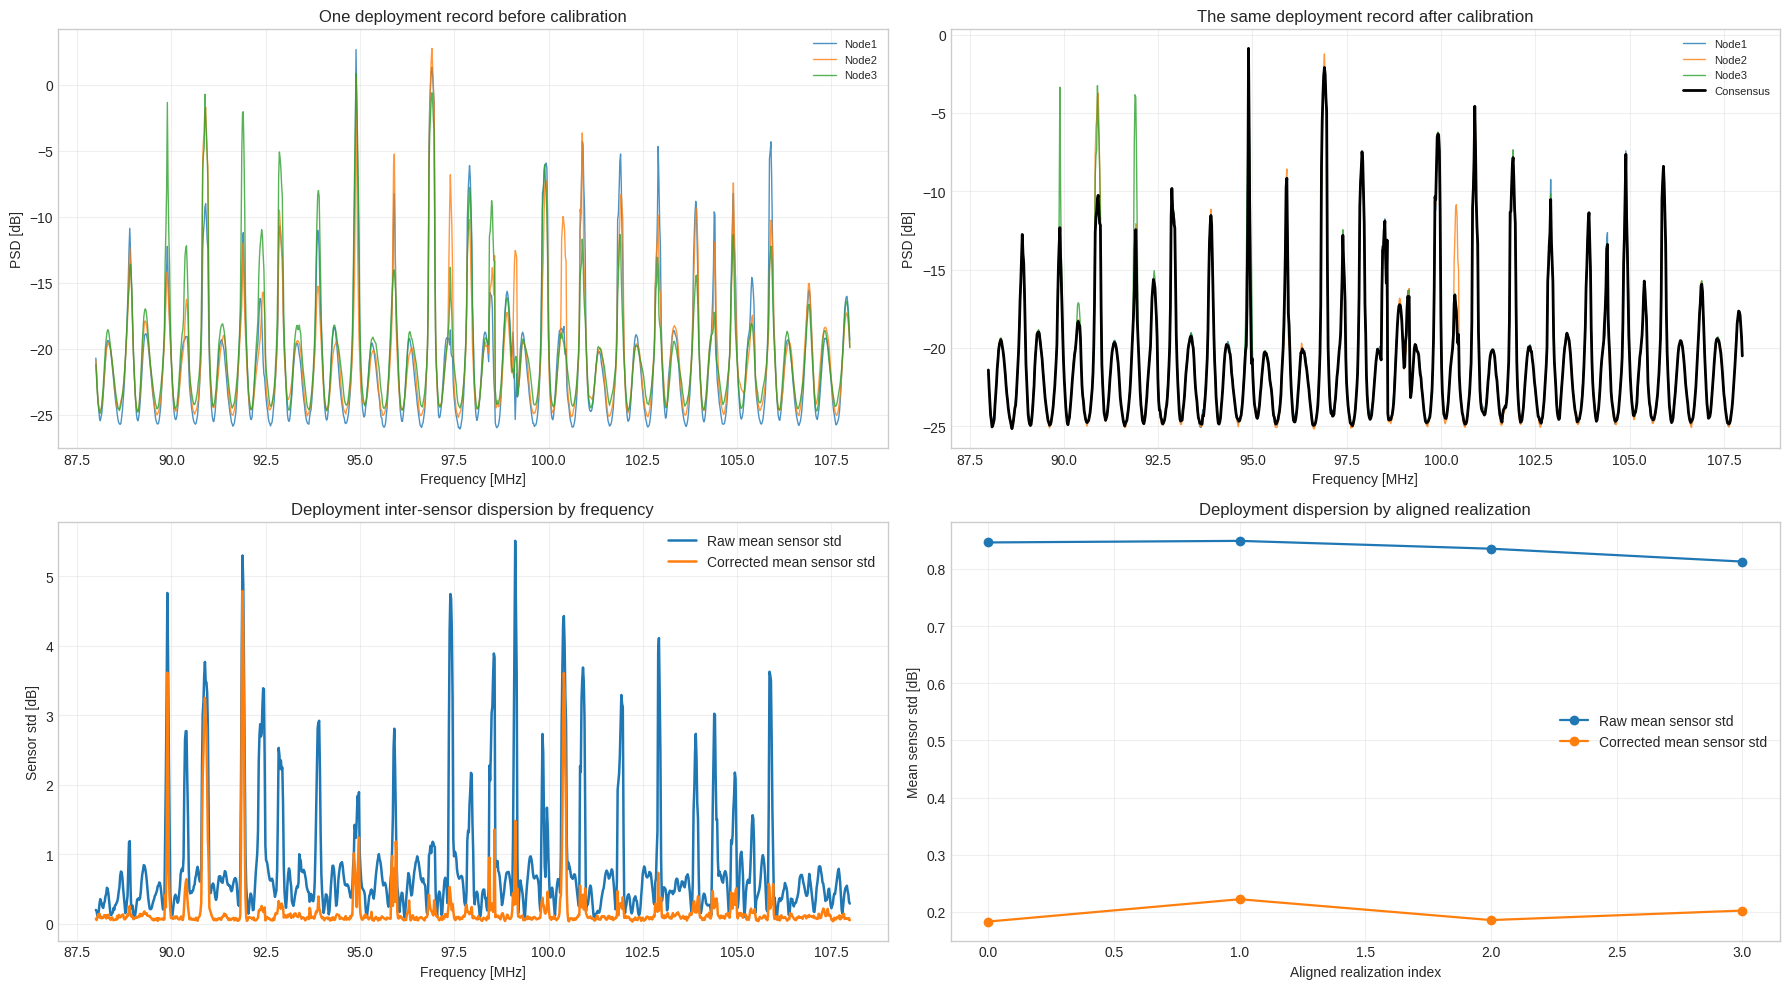

In [4]:
plot_stride = max(1, deployment_inputs.frequency_hz.size // PLOT_STRIDE_TARGET)
freq_mhz = deployment_inputs.frequency_hz[::plot_stride] / 1e6
mean_raw_record_dispersion_db = np.mean(raw_dispersion_db, axis=1)
mean_corrected_record_dispersion_db = np.nanmean(
    corrected_plot_dispersion_db,
    axis=1,
)
selected_record_index = int(np.argmax(mean_raw_record_dispersion_db))

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.ravel()
for sensor_index, sensor_id in enumerate(deployment_inputs.shared_sensor_ids):
    axes[0].plot(
        freq_mhz,
        raw_db[sensor_index, selected_record_index, ::plot_stride],
        linewidth=1.0,
        alpha=0.80,
        label=sensor_id,
    )
    axes[1].plot(
        freq_mhz,
        corrected_plot_db[sensor_index, selected_record_index, ::plot_stride],
        linewidth=1.0,
        alpha=0.80,
        label=sensor_id,
    )
axes[1].plot(
    freq_mhz,
    consensus_db[selected_record_index, ::plot_stride],
    color="black",
    linewidth=2.0,
    label="Consensus",
)
axes[0].set_title("One deployment record before calibration")
axes[1].set_title("The same deployment record after calibration")
for axis in axes[:2]:
    axis.set_xlabel("Frequency [MHz]")
    axis.set_ylabel("PSD [dB]")
    axis.grid(True, alpha=0.30)
axes[0].legend(fontsize=8)
axes[1].legend(fontsize=8)

axes[2].plot(
    freq_mhz,
    np.mean(raw_dispersion_db, axis=0)[::plot_stride],
    linewidth=1.8,
    label="Raw mean sensor std",
)
axes[2].plot(
    freq_mhz,
    np.nanmean(corrected_plot_dispersion_db, axis=0)[::plot_stride],
    linewidth=1.8,
    label="Corrected mean sensor std",
)
axes[2].set_title("Deployment inter-sensor dispersion by frequency")
axes[2].set_xlabel("Frequency [MHz]")
axes[2].set_ylabel("Sensor std [dB]")
axes[2].grid(True, alpha=0.30)
axes[2].legend()

axes[3].plot(
    np.arange(raw_power.shape[1]),
    mean_raw_record_dispersion_db,
    marker="o",
    linewidth=1.6,
    label="Raw mean sensor std",
)
axes[3].plot(
    np.arange(raw_power.shape[1]),
    mean_corrected_record_dispersion_db,
    marker="o",
    linewidth=1.6,
    label="Corrected mean sensor std",
)
axes[3].set_title("Deployment dispersion by aligned realization")
axes[3].set_xlabel("Aligned realization index")
axes[3].set_ylabel("Mean sensor std [dB]")
axes[3].grid(True, alpha=0.30)
axes[3].legend()

plt.tight_layout()
print(
    f"Visualized deployment record index: {selected_record_index} of {raw_power.shape[1] - 1}"
)
